In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.funcionesTransform import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                18028 non-null  datetime64[ns]
 1   Close               18028 non-null  float64       
 2   Ticker              18028 non-null  object        
 3   MonthlyReturn       17550 non-null  float64       
 4   MonthlyVariance     17550 non-null  float64       
 5   MarketCovariance    17550 non-null  float64       
 6   BasicAvgShares      17977 non-null  float64       
 7   MarketCap           17977 non-null  float64       
 8   EnterpriseValue     17977 non-null  float64       
 9   TrailingPE          17938 non-null  float64       
 10  EnterpriseToEbitda  17977 non-null  float64       
 11  PriceToBook         17938 non-null  float64       
 12  OperatingMargins    18028 non-null  float64       
 13  ProfitMargins       17989 non-null  float64   

# Missing Values

In [3]:
# Incidencia de missings en columnas numéricas
df.select_dtypes(include='number').apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Capex_YoY             0.315676
Revenue_YoY           0.302252
EBITDA_YoY            0.302252
FCF_YoY               0.302252
Capex_QoQ             0.093632
FCF_QoQ               0.075716
Revenue_QoQ           0.075716
EBITDA_QoQ            0.075716
MonthlyReturn         0.026514
MonthlyVariance       0.026514
MarketCovariance      0.026514
Capex_to_Revenue      0.019414
PriceToBook           0.004992
TrailingPE            0.004992
ReturnOnEquity        0.004327
BasicAvgShares        0.002829
MarketCap             0.002829
EnterpriseToEbitda    0.002829
EnterpriseValue       0.002829
DebtToEquity          0.002163
ProfitMargins         0.002163
ReturnOnAssets        0.002163
TotalEquity           0.002163
NetDebt_to_EBITDA     0.002163
OperatingMargins      0.000000
Close                 0.000000
CurrentRatio          0.000000
FCF_to_EBITDA         0.000000
TotalAssets           0.000000
TotalRevenue          0.000000
dtype: float64

In [4]:
# Incidencia de missings en columnas no numéricas
df_non_numeric = df.select_dtypes(exclude='number')
df_non_numeric.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Date         0.0
Ticker       0.0
Sector       0.0
DateAdded    0.0
dtype: float64

In [5]:
# Imputación multivariable con IterativeImputer sobre numéricas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont = df.select_dtypes(include='number')

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               18028 non-null  float64
 1   MonthlyReturn       18028 non-null  float64
 2   MonthlyVariance     18028 non-null  float64
 3   MarketCovariance    18028 non-null  float64
 4   BasicAvgShares      18028 non-null  float64
 5   MarketCap           18028 non-null  float64
 6   EnterpriseValue     18028 non-null  float64
 7   TrailingPE          18028 non-null  float64
 8   EnterpriseToEbitda  18028 non-null  float64
 9   PriceToBook         18028 non-null  float64
 10  OperatingMargins    18028 non-null  float64
 11  ProfitMargins       18028 non-null  float64
 12  ReturnOnEquity      18028 non-null  float64
 13  ReturnOnAssets      18028 non-null  float64
 14  DebtToEquity        18028 non-null  float64
 15  CurrentRatio        18028 non-null  float64
 16  Reve

In [6]:
# Se vuelven a unir las columnas numéricas y no numéricas
df_imputed = pd.concat([df_cont_imputed, df_non_numeric], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Close               18028 non-null  float64       
 1   MonthlyReturn       18028 non-null  float64       
 2   MonthlyVariance     18028 non-null  float64       
 3   MarketCovariance    18028 non-null  float64       
 4   BasicAvgShares      18028 non-null  float64       
 5   MarketCap           18028 non-null  float64       
 6   EnterpriseValue     18028 non-null  float64       
 7   TrailingPE          18028 non-null  float64       
 8   EnterpriseToEbitda  18028 non-null  float64       
 9   PriceToBook         18028 non-null  float64       
 10  OperatingMargins    18028 non-null  float64       
 11  ProfitMargins       18028 non-null  float64       
 12  ReturnOnEquity      18028 non-null  float64       
 13  ReturnOnAssets      18028 non-null  float64   

# Transformaciones

In [7]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)

In [8]:
# Se expresan columnas monetarias en billions
columnas_monetarias = ['MarketCap', 'EnterpriseValue', 'TotalAssets', 'TotalRevenue', 'TotalEquity']

for col in columnas_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [9]:
#  Pasar DateAdded a formato datetime y transformar a YearsSinceAdded
df_transformed['DateAdded'] = pd.to_datetime(df_transformed['DateAdded'], errors='coerce')
df_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_transformed['DateAdded']).dt.days / 365.25), 0)
df_transformed.drop('DateAdded', axis=1, inplace=True)

In [10]:
# Convertir Sector a category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2881
HealthCare               2238
ConsumerDiscretionary    1900
ConsumerStaples          1466
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    819
Name: count, dtype: int64

In [11]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Close,18028.0,197.3835,1.388,63.1223,117.0907,217.2993,9811.7998,411.1714
MonthlyReturn,18028.0,0.0153,-0.5197,-0.0396,0.0121,0.0617,1.4275,0.0963
MonthlyVariance,18028.0,0.009,-0.0042,0.0036,0.006,0.0099,0.3652,0.0141
MarketCovariance,18028.0,0.0017,-0.004,0.0006,0.0014,0.0024,0.017,0.0015
BasicAvgShares,18028.0,795670991.8633,2900000.0,157468000.0,335187000.0,696026000.0,24870000000.0,1861640843.6394
MarketCap,18028.0,107.9209,0.6997,18.3277,35.3118,77.1524,5137.1721,348.2907
EnterpriseValue,18028.0,120.0305,3.1643,23.1412,44.0006,91.3197,5137.6071,352.6959
TrailingPE,18028.0,-14.0862,-101202.9506,15.4196,24.249,36.5592,5658.6473,1980.7521
EnterpriseToEbitda,18028.0,22.8673,-1813.3252,11.1037,15.8743,22.206,3204.6996,91.3269
PriceToBook,18028.0,7.405,-1113.1821,1.8852,3.7723,8.1108,1357.7175,50.8733


In [12]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew()

Close                 13.150755
MonthlyReturn          1.608427
MonthlyVariance       11.541409
MarketCovariance       1.344215
BasicAvgShares         7.562923
MarketCap              8.292770
EnterpriseValue        8.154978
TrailingPE           -39.431535
EnterpriseToEbitda    13.325458
PriceToBook            8.219102
OperatingMargins      -0.432521
ProfitMargins         -1.912444
ReturnOnEquity         4.155084
ReturnOnAssets         0.691150
DebtToEquity          -2.177240
CurrentRatio           6.683361
Revenue_YoY            3.981383
Revenue_QoQ            8.353787
EBITDA_YoY           -12.933244
EBITDA_QoQ           -24.281199
FCF_YoY               25.379512
FCF_QoQ               46.924456
Capex_YoY            -36.091838
Capex_QoQ            -73.340196
NetDebt_to_EBITDA      3.030183
FCF_to_EBITDA         13.746321
Capex_to_Revenue       2.862893
TotalAssets            3.693064
TotalRevenue           5.112157
TotalEquity            5.847091
RelativeAssets        48.281517
Relative

Cont


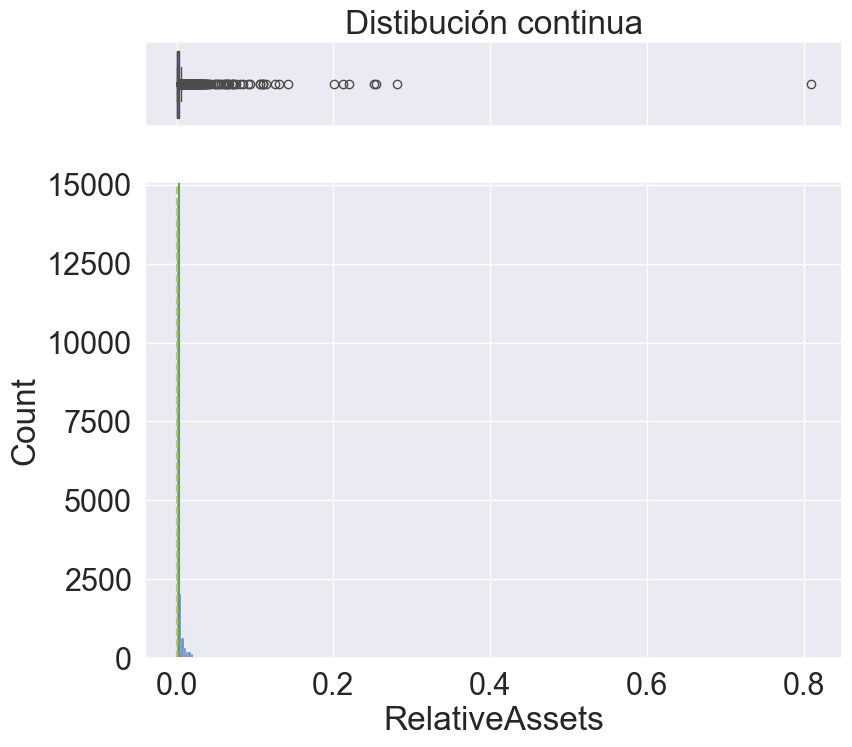

In [13]:
# Graficar
columna_a_graficar = 'RelativeAssets' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [14]:
# Transformaciones yeo-johnson
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = [
    'ReturnOnEquity', 
    'DebtToEquity'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_Transformed'] = pt.fit_transform(df_transformed[[columna]])
    # Elimino la columna sin transformar
    df_transformed.drop(columna, axis=1, inplace=True)

In [15]:
# Transformaciones logarítmicas
columnas_a_transformar = [
    'RelativeAssets', 
    'RelativeRevenue', 
    'Close',
    'MarketCap',
    'CurrentRatio'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_log'] = np.log(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew()

MonthlyReturn                  1.608427
MonthlyVariance               11.541409
MarketCovariance               1.344215
BasicAvgShares                 7.562923
EnterpriseValue                8.154978
TrailingPE                   -39.431535
EnterpriseToEbitda            13.325458
PriceToBook                    8.219102
OperatingMargins              -0.432521
ProfitMargins                 -1.912444
ReturnOnAssets                 0.691150
Revenue_YoY                    3.981383
Revenue_QoQ                    8.353787
EBITDA_YoY                   -12.933244
EBITDA_QoQ                   -24.281199
FCF_YoY                       25.379512
FCF_QoQ                       46.924456
Capex_YoY                    -36.091838
Capex_QoQ                    -73.340196
NetDebt_to_EBITDA              3.030183
FCF_to_EBITDA                 13.746321
Capex_to_Revenue               2.862893
TotalAssets                    3.693064
TotalRevenue                   5.112157
TotalEquity                    5.847091


In [16]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = [
    'MarketCap_log',
    'Close_log',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    'EnterpriseValue',
    'TotalAssets',
    'TotalRevenue',
    'TotalEquity',
    'BasicAvgShares', 
    'Date', 
    'Ticker'        
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [17]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

MonthlyReturn
MonthlyVariance
MarketCovariance
OperatingMargins
ProfitMargins
ReturnOnAssets
Revenue_YoY
Revenue_QoQ
EBITDA_YoY
EBITDA_QoQ
FCF_YoY
FCF_QoQ
Capex_YoY
Capex_QoQ
NetDebt_to_EBITDA
FCF_to_EBITDA
Capex_to_Revenue
YearsSinceAdded
ReturnOnEquity_Transformed
DebtToEquity_Transformed
RelativeAssets_log
RelativeRevenue_log
CurrentRatio_log


In [18]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew()

MonthlyReturn                 0.470153
MonthlyVariance               1.753854
MarketCovariance              1.023331
OperatingMargins              0.454687
ProfitMargins                 0.123042
ReturnOnAssets                0.567798
Revenue_YoY                   0.175441
Revenue_QoQ                  -0.837824
EBITDA_YoY                    0.456978
EBITDA_QoQ                   -2.895004
FCF_YoY                       0.769209
FCF_QoQ                      -0.978780
Capex_YoY                    -0.793304
Capex_QoQ                     1.960363
NetDebt_to_EBITDA             0.350950
FCF_to_EBITDA                -0.237955
Capex_to_Revenue              1.692724
YearsSinceAdded               1.029011
ReturnOnEquity_Transformed   -0.000799
DebtToEquity_Transformed      0.170419
RelativeAssets_log            0.274606
RelativeRevenue_log           0.629975
CurrentRatio_log              0.456212
dtype: float64

Cont


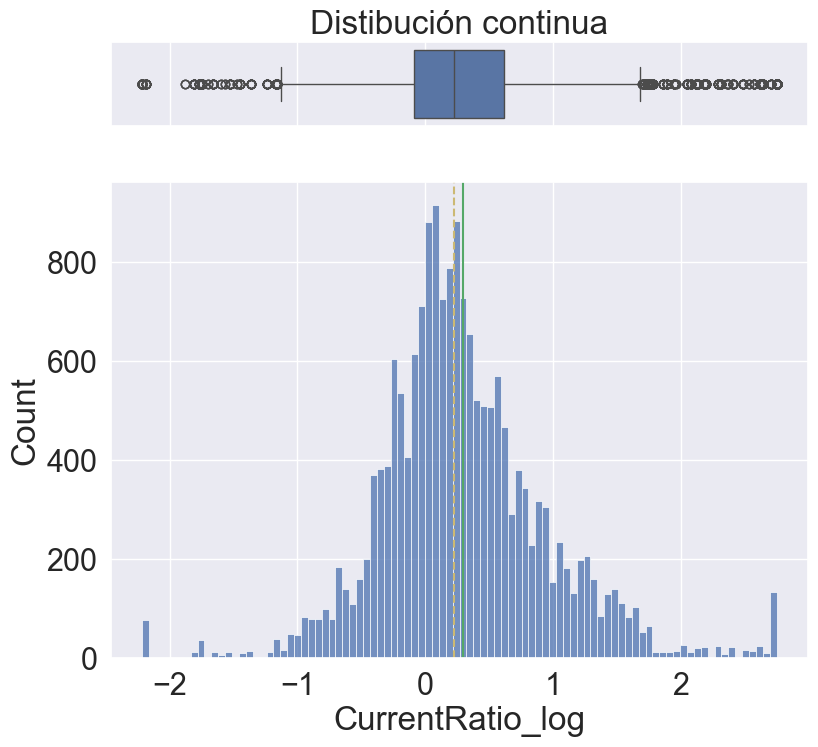

In [19]:
# Visualizar cambios
columna_a_graficar = 'CurrentRatio_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [20]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
MonthlyReturn,18028.0,0.014137,0.089372,-0.348050,-0.039612,0.012106,0.061670,0.366073
MonthlyVariance,18028.0,0.007922,0.006293,-0.004174,0.003642,0.005993,0.009851,0.028485
MarketCovariance,18028.0,0.001648,0.001478,-0.003955,0.000644,0.001418,0.002389,0.007635
OperatingMargins,18028.0,0.189334,0.141715,-0.398900,0.102500,0.177200,0.257600,0.741900
ProfitMargins,18028.0,0.134279,0.130782,-0.353200,0.065400,0.120100,0.195400,0.603100
ReturnOnAssets,18028.0,0.078485,0.077444,-0.227700,0.032300,0.062800,0.116600,0.388700
Revenue_YoY,18028.0,0.052001,0.105844,-0.270178,0.003607,0.046775,0.092986,0.362387
Revenue_QoQ,18028.0,0.000003,0.000012,-0.000033,0.000000,0.000000,0.000000,0.000020
EBITDA_YoY,18028.0,0.131350,0.353330,-0.822253,-0.015432,0.098550,0.253471,1.062149
EBITDA_QoQ,18028.0,-0.000018,0.000091,-0.000320,0.000000,0.000000,0.000000,0.000038


## Concatenación final de columnas

In [21]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   MarketCap_log               18028 non-null  float64       
 1   Close_log                   18028 non-null  float64       
 2   TrailingPE                  18028 non-null  float64       
 3   EnterpriseToEbitda          18028 non-null  float64       
 4   PriceToBook                 18028 non-null  float64       
 5   EnterpriseValue             18028 non-null  float64       
 6   TotalAssets                 18028 non-null  float64       
 7   TotalRevenue                18028 non-null  float64       
 8   TotalEquity                 18028 non-null  float64       
 9   BasicAvgShares              18028 non-null  float64       
 10  Date                        18028 non-null  datetime64[ns]
 11  Ticker                      18028 non-null  object    

In [22]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")